# Entrega 4 - Modelos de segmentación

**Autor: Emilio Alarcón Gómez**

**Correo Electrónico: emilio.alarcon2101@alumnos.ubiobio.cl**

**Fecha de Creación:** Junio 2025

**Versión:** 1.0  



---

## Descripción


Este notebook contiene el desarrollo de la evaluación 4 de la asignatura de Inteligencia Artificial de la carrera de Ingeniería en Informática - Sede Concepción

---

## Requisitos de Software

Este notebook fue desarrollado con Python 3.9. A continuación se listan las bibliotecas necesarias:

- numpy (2.0.2)
- pandas (2.2.2)
- matplotlib (3.10.0)
- seaborn (0.13.2)

Para verificar la versión instalada ejecutar usando el siguiente comando, usando la librería de la cual quieres saber la versión:

```bash
import pandas as pd
print(pd.__version__)
````

In [ ]:
!wget https://raw.githubusercontent.com/JaznaLaProfe/InteligenciaArtificial/main/data/datos_segmentacion.csv

--2025-07-10 22:24:53--  https://raw.githubusercontent.com/JaznaLaProfe/InteligenciaArtificial/main/data/datos_segmentacion.csv
Resolving raw.githubusercontent.com (raw.githubusercontent.com)... 185.199.108.133, 185.199.109.133, 185.199.110.133, ...
Connecting to raw.githubusercontent.com (raw.githubusercontent.com)|185.199.108.133|:443... connected.
HTTP request sent, awaiting response... 200 OK
Length: 159876 (156K) [text/plain]
Saving to: ‘datos_segmentacion.csv’

datos_segmentacion. 100%[===================>] 156.13K  --.-KB/s    in 0.04s   

2025-07-10 22:24:54 (3.47 MB/s) - ‘datos_segmentacion.csv’ saved [159876/159876]



In [ ]:
print(pd.__version__)
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score
from sklearn.decomposition import PCA

2.2.2


# Objetivos



## Contexto de Negocio para Segmentación

**Nombre del proyecto:** Segmentación de Usuarios de una App de Bienestar Integral

**Contexto:**
Una startup tecnológica ha desarrollado una aplicación móvil llamada **ViveFit**, orientada a mejorar el bienestar de las personas mediante el monitoreo de su actividad física y calidad del descanso.

A través de sensores y autodiagnóstico diario, la aplicación recolecta las siguientes variables continuas para cada usuario:

* `actividad_fisica`: horas promedio de ejercicio semanal.
* `pasos_diarios`: promedio de pasos diarios registrados.
* `calorias_gastadas`: estimación promedio de calorías quemadas por actividad.
* `horas_de_sueno`: promedio de horas de sueño nocturno.
* `nivel_descanso`: índice (numérico) que refleja cuán descansado se siente el usuario (basado en sueño y hábitos).

**Objetivo de análisis:**
La empresa desea **segmentar a sus usuarios** para personalizar recomendaciones, notificaciones y planes de entrenamiento. El equipo de analítica ha decidido aplicar técnicas de **reducción de dimensionalidad con PCA**, con el fin de visualizar la estructura de los datos y mejorar la calidad de segmentación.

---

## Actividades

### Modelo usando 2 variables
1. Justificar la selección de 2 variables **(5 puntos)**
2. Elegir la cantidad óptima de clusters **(3 puntos)**
3. Aplicar **KMeans** usando 2 variables y evaluar la calidad de los grupos generados. **(2 puntos)**
4. Visualizar los grupos generados mostrando los centroides de cada grupo. **(3 puntos)**
5. Mostrar los **centroides en escala original**. **(3 puntos)**
6. Interpretar un **centroide en escala original**. **(3 puntos)**
### Modelo usando 4 o más variables
7. Justificar la selección de las variables **(5 puntos)**
8. Elegir la cantidad óptima de clusters **(3 puntos)**
9. Aplicar **KMeans** usando las variables seleccionadas y evaluar la calidad de los grupos generados. **(2 puntos)**
10. Mostrar los **centroides en escala original**. **(3 puntos)**
11. Interpretar un **centroide en escala original**. **(3 puntos)**
12. **Aplicar PCA** sobre los datos escalados y argumentar cuántos componentes principales retendrán. **(5 puntos - 1 punto aplicar PCA y 4 por argumentar correctamente)**
13. Visualizar la **varianza explicada acumulada** para justificar la elección. **(2 puntos)**
14. Mostrar los **centroides en escala original**. **(3 puntos)**



---

## Penalizaciones
+ Ausencia de datos de autores - 10% de la calificación final
+ Falta de aplicación de buenas prácticas - 10% de la calificación final
* Faltas en redacción y ortografía - 10% de la calificación final

---


## Modelo de segmentación usando 2 variables

### Selección y justificación de variables

In [ ]:
df = pd.read_csv('datos_segmentacion.csv')
df.head()

,actividad_fisica,pasos_diarios,calorias_gastadas,horas_de_sueno,nivel_descanso
0,5.75,11278.26,2230.18,7.40,75.74
1,4.79,9358.50,1886.49,7.48,76.19
2,5.97,11045.24,2328.88,7.55,70.77
3,7.28,14404.04,2924.86,8.16,84.53
4,4.65,9663.95,1979.23,6.98,62.32


**Justificación**

Se eligen las variables 'actividad_fisica' y 'horas_de_sueno' porque ambas reflejan hábitos fundamentales de salud y bienestar de los usuarios. Su combinación puede ayudar a distinguir usuarios físicamente activos pero con poco descanso o con hábitos opuestos.

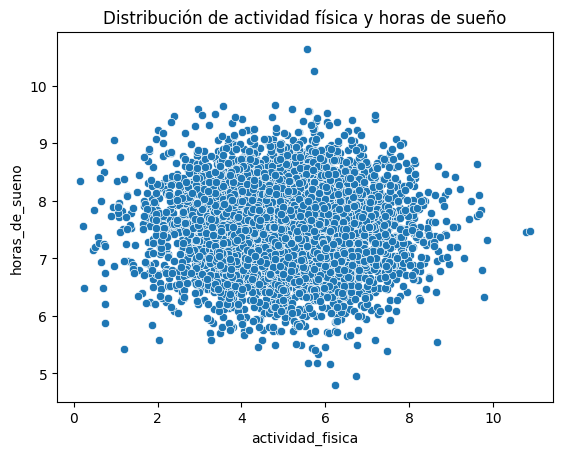

In [ ]:
# Selección de las dos variables
vars_2 = ['actividad_fisica', 'horas_de_sueno']
df_2 = df[vars_2]

# Visualización
sns.scatterplot(x='actividad_fisica', y='horas_de_sueno', data=df)
plt.title('Distribución de actividad física y horas de sueño')
plt.show()

**Interpretación**

Se observa que la mayoría de los usuarios se agrupan en torno a valores medios tanto de actividad física como de horas de sueño, aunque existe cierta dispersión en ambos sentidos. Esto sugiere que hay diversidad en los hábitos de los usuarios, convendría la aplicación de técnicas de segmentación para identificar grupos con características similares.

No hay valores extremos predominantes por lo que ambos hábitos varían de forma independiente entre los usuarios respaldando la elección de estas variables.

### Elección del número de cluster óptimo

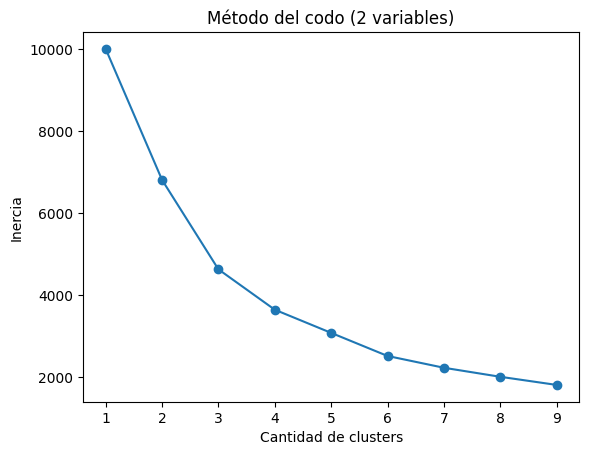

In [ ]:
# Escalamiento
scaler = StandardScaler()
df_2_scaled = scaler.fit_transform(df_2)

# Cálculo de inercia
inertia = []
K = range(1, 10)
for k in K:
    kmeans = KMeans(n_clusters=k, random_state=42)
    kmeans.fit(df_2_scaled)
    inertia.append(kmeans.inertia_)

plt.figure()
plt.plot(K, inertia, marker='o')
plt.xlabel('Cantidad de clusters')
plt.ylabel('Inercia')
plt.title('Método del codo (2 variables)')
plt.show()

**Interpretación**

Se observa que la inercia disminuye rápidamente hasta el punto correspondiente a 3 clusters, momento en que la reducción comienza a ser menos pronunciada. Esto indica que el modelo KMeans logra captar la mayor parte de la estructura de los datos utilizando tres grupos. Por lo tanto, se seleccionarán 3 clusters como cantidad óptima para segmentar a los usuarios.

### Creación y entrenamiento del modelo

In [ ]:
# Entrenamiento con 3 clusters
n_clusters = 3
kmeans_2 = KMeans(n_clusters=n_clusters, random_state=42)
labels_2 = kmeans_2.fit_predict(df_2_scaled)

# Evaluación del modelo con el coeficiente de silueta
score = silhouette_score(df_2_scaled, labels_2)
print(f'Coeficiente de silueta para {n_clusters} clusters: {score:.2f}')

Coeficiente de silueta para 3 clusters: 0.33


**Interpretación**

El coeficiente obtenido fue de 0.33, esto indica que los grupos presentan una separación aceptable, aunque no óptima. Este valor sugiere que los usuarios dentro de cada cluster comparten patrones relativamente similares de actividad física y horas de sueño, pero existe cierto solapamiento entre los grupos.

### Evaluación del modelo

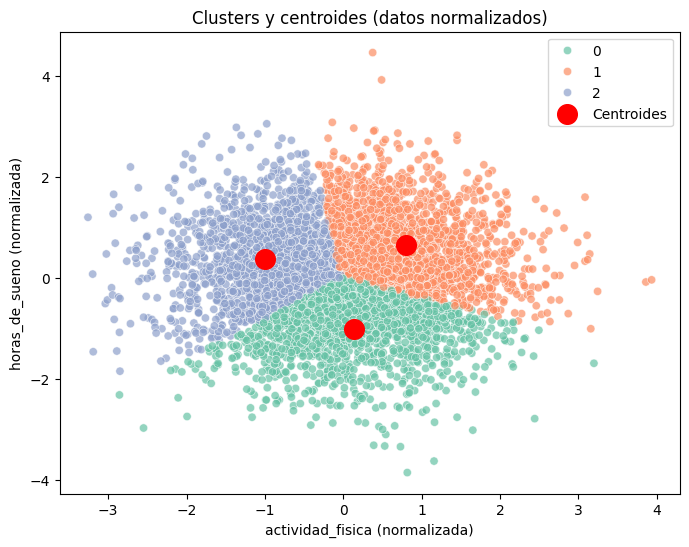

In [ ]:
plt.figure(figsize=(8,6))
sns.scatterplot(x=df_2_scaled[:,0], y=df_2_scaled[:,1], hue=labels_2, palette="Set2", alpha=0.7)
plt.scatter(kmeans_2.cluster_centers_[:,0], kmeans_2.cluster_centers_[:,1], s=200, c='red', label='Centroides')
plt.xlabel('actividad_fisica (normalizada)')
plt.ylabel('horas_de_sueno (normalizada)')
plt.title('Clusters y centroides (datos normalizados)')
plt.legend()
plt.show()

**Interpretación**

Se observa que los usuarios se agrupan de manera diferenciada en tres segmentos principales. La ubicación de los centroides permite identificar los perfiles predominantes dentro de cada grupo. La segmentación evidencia que existen patrones diferenciados de comportamiento respecto a la actividad física y el descanso, lo que resulta útil para el diseño de estrategias de personalización en la aplicación.

In [ ]:
# Centroides a escala original
centroides = scaler.inverse_transform(kmeans_2.cluster_centers_)
centroides_df = pd.DataFrame(centroides, columns=vars_2)
print('Centroides en escala original:')
print(centroides_df)

Centroides en escala original:
   actividad_fisica  horas_de_sueno
0          5.219362        6.797918
1          6.198230        7.968709
2          3.525409        7.767990


**Interpretación**

El centroide correspondiente al Cluster 1 presenta valores promedio de actividad física superior al promedio y tienden a dormir más horas. Este perfil puede asociarse a personas con hábitos saludables lo que podría influir positivamente en su bienestar general.

La identificación de este tipo de perfiles permite personalizar las recomendaciones de la aplicación.

## Modelo de segmentación usando 4 o más variables

### Selección de las variables

In [ ]:
# Selección y escalado
vars_5 = ['actividad_fisica', 'pasos_diarios', 'calorias_gastadas', 'horas_de_sueno', 'nivel_descanso']
df_5 = df[vars_5]
scaler_5 = StandardScaler()
df_5_scaled = scaler_5.fit_transform(df_5)

**Interpretación**

La combinación de todas las variables permite una segmentación más precisa de los usuarios, facilitando la identificación de grupos con diferentes estilos de vida y necesidades específicas. Esto resulta útil para diseñar recomendaciones personalizadas y estrategias de mejora en la aplicación.

### Selección de número de clusters óptimo

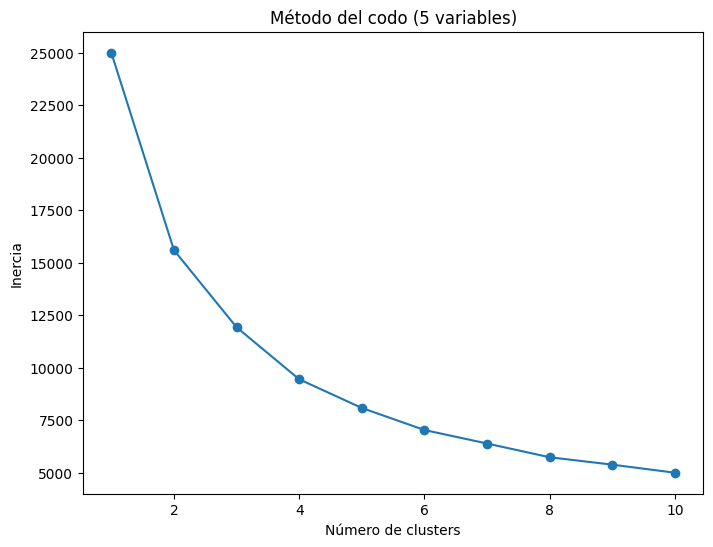

In [ ]:
# Método del codo
inertia = []
for k in range(1, 11):
    kmeans = KMeans(n_clusters=k, random_state=42)
    kmeans.fit(df_5_scaled)
    inertia.append(kmeans.inertia_)

plt.figure(figsize=(8,6))
plt.plot(range(1, 11), inertia, marker='o')
plt.xlabel('Número de clusters')
plt.ylabel('Inercia')
plt.title('Método del codo (5 variables)')
plt.show()

**Interpretación**

El codo del gráfico se localiza alrededor de los 3 clusters, lo que indica que, a partir de este valor, el beneficio de agregar más grupos disminuye considerablemente. Por lo tanto, se seleccionan 3 clusters como número óptimo para el modelo.

### Creación y entrenamiento del modelo

In [ ]:
# Entrenamiento
kmeans_5 = KMeans(n_clusters=3, random_state=42)
labels_5 = kmeans_5.fit_predict(df_5_scaled)

# Evaluación
silhouette_5 = silhouette_score(df_5_scaled, labels_5)
print(f'Coeficiente de silueta para 3 clusters: {silhouette_5:.2f}')

Coeficiente de silueta para 3 clusters: 0.29


**Interpretación**

Se obtuvo un valor de 0.29, esto indica una separación moderada entre los grupos formados. Si bien los clusters son distinguibles, existe cierto grado de solapamiento entre las fronteras de los grupos, lo cual es habitual en datos reales con múltiples variables relacionadas.
Sin embargo, el modelo permite identificar perfiles diferenciados de usuarios, lo que resulta útil para el análisis y la personalización de recomendaciones en la aplicación.

### Evaluación del modelo

In [ ]:
# Transformar los centroides a escala original
centroides_5 = scaler_5.inverse_transform(kmeans_5.cluster_centers_)
centroides_5_df = pd.DataFrame(centroides_5, columns=vars_5)
print('Centroides en escala original:')
print(centroides_5_df)

Centroides en escala original:
   actividad_fisica  pasos_diarios  calorias_gastadas  horas_de_sueno  \
0          5.063302   10128.330209        2023.393942        6.838470   
1          6.346737   12706.839657        2546.462776        7.832615   
2          3.548907    7067.829451        1416.131122        7.756622   

   nivel_descanso  
0       66.961509  
1       78.906343  
2       77.920777  


**Interpretación**

El centroide correspondiente al Cluster 1 representa a usuarios que, en promedio, realizan una mayor cantidad de actividad física diaria, alcanzan un elevado número de pasos y gastan más calorías en comparación con los otros clusters. Además, presentan valores superiores tanto en las horas de sueño como en el nivel de descanso, lo que sugiere que mantienen hábitos saludables tanto en el ejercicio como en el reposo.

La identificación de este perfil resulta relevante para la aplicación, ya que permite reconocer usuarios con comportamientos óptimos de bienestar y adaptar las estrategias de comunicación para reforzar y mantener estos hábitos positivos.

### Aplicación de PCA

Varianza explicada acumulada: [0.59271584 0.95515384 0.99263172 0.99815579 1.        ]


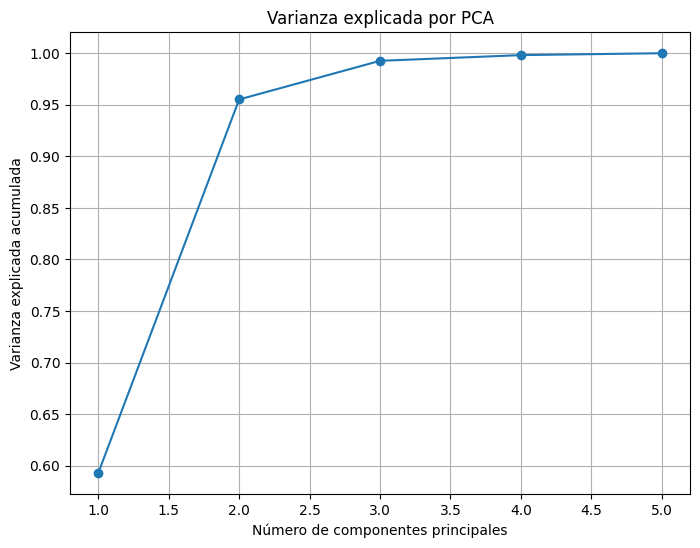

In [ ]:
# PCA a los datos escalados
pca = PCA()
pca.fit(df_5_scaled)

# Varianza explicada acumulada
varianza_acumulada = np.cumsum(pca.explained_variance_ratio_)
print('Varianza explicada acumulada:', varianza_acumulada)

# Visualización de la varianza
plt.figure(figsize=(8,6))
plt.plot(range(1, len(varianza_acumulada)+1), varianza_acumulada, marker='o')
plt.xlabel('Número de componentes principales')
plt.ylabel('Varianza explicada acumulada')
plt.title('Varianza explicada por PCA')
plt.grid()
plt.show()

**Interpretación**

- El primer componente principal explica aproximadamente el 59% de la varianza.
- Con dos componentes principales se alcanza el 95.5% de la varianza explicada.
- Con tres componentes se supera el 99% de la varianza acumulada.

Por lo tanto, se decide retener dos componentes principales.

Se recomienda conservar suficientes componentes para explicar al menos el 80% de la varianza. En este caso, se observa que dos componentes principales son suficientes para representar la mayor parte de la información del conjunto de datos, permitiendo así una reducción significativa de la dimensionalidad sin una pérdida considerable de información relevante.

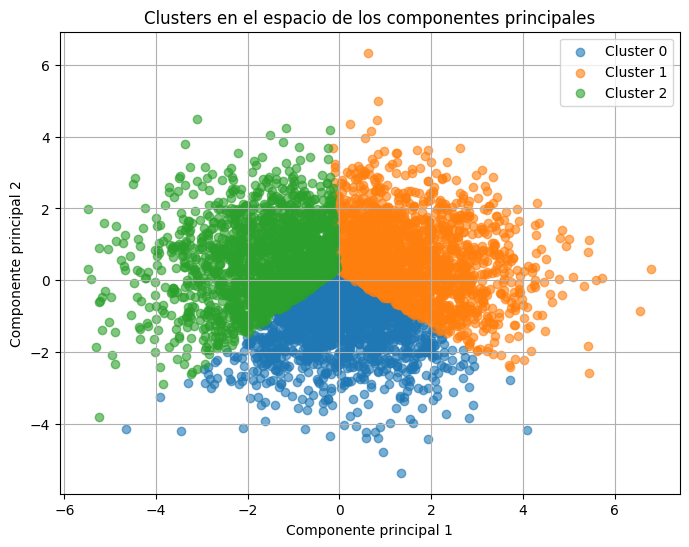

In [ ]:
# Proyectar datos
df_pca_2 = pca.transform(df_5_scaled)[:, :2]

# Visualización
plt.figure(figsize=(8,6))
for i in range(3):
    plt.scatter(df_pca_2[labels_5 == i, 0], df_pca_2[labels_5 == i, 1], label=f'Cluster {i}', alpha=0.6)

plt.xlabel('Componente principal 1')
plt.ylabel('Componente principal 2')
plt.title('Clusters en el espacio de los componentes principales')
plt.legend()
plt.grid()
plt.show()

**Interpretación**

Se observa que los grupos presentan una separación clara en el espacio bidimensional, lo que confirma la utilidad de la reducción de dimensionalidad mediante PCA para visualizar la segmentación generada. La estructura triangular sugiere que los perfiles identificados por el modelo presentan diferencias notables en las combinaciones de las variables originales.